In [83]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os
import glob
import rasterio
import tqdm

In [84]:
all_indices = [
    'NDVI',
    'NGRDI',
    'RVI',
    'EXGR'
]

In [85]:
def norm_index_image(image, min, max):
    norm_image = np.clip(image, min, max)
    norm_image = ((norm_image - min) / (max - min) * 255).astype(np.uint8)
    return norm_image

float32
(1024, 1024)
Max img value:  0.80867165
Min img value:  -0.04628708
uint8
(1024, 1024)
Max img value:  230
Min img value:  121


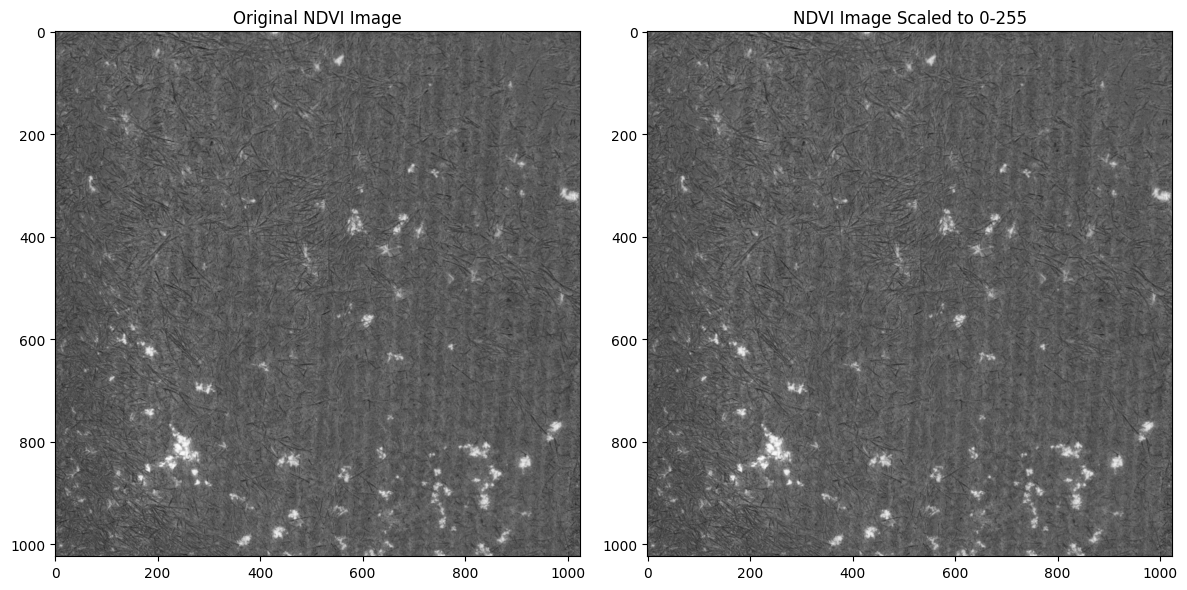

Saved UTF-8 encoded image to /home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_ndvi_255.tif


100%|██████████| 714/714 [00:08<00:00, 86.51it/s]


In [86]:
IMAGE_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/NDVI/tile_1_7_ndvi.tif"

with rasterio.open(IMAGE_PATH) as src:
    img = src.read(1)

print(img.dtype)
print(img.shape)
print("Max img value: ", img.max())
print("Min img value: ", img.min())


ndvi_min = -1.00
ndvi_max = 1.00
ndvi = img.astype(np.float32)
ndvi_clipped = np.clip(ndvi, ndvi_min, ndvi_max)
ndvi_norm = np.floor(((ndvi_clipped + 1) / 2) * 255).astype(np.uint8)

print(ndvi_norm.dtype)
print(ndvi_norm.shape)
print("Max img value: ", ndvi_norm.max())
print("Min img value: ", ndvi_norm.min())

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original NDVI Image")
plt.imshow(img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("NDVI Image Scaled to 0-255")
plt.imshow(ndvi_norm, cmap='gray')

plt.tight_layout()
plt.show()

# Save the UTF-8 encoded image
output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_ndvi_255.tif"
with rasterio.open(output_path, 'w', driver='GTiff', height=ndvi_norm.shape[0],
                   width=ndvi_norm.shape[1], count=1, dtype=ndvi_norm.dtype) as dst:
    dst.write(ndvi_norm, 1)
print(f"Saved UTF-8 encoded image to {output_path}")

#save original image for comparison
original_output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_ndvi_original.tif"
with rasterio.open(original_output_path, 'w', driver='GTiff', height=img.shape[0],
                   width=img.shape[1], count=1, dtype=img.dtype) as dst:
    dst.write(img, 1)

    INPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/NDVI"
OUTPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces_utf8/NDVI"

os.makedirs(OUTPUT_PATH, exist_ok=True)


for filepath in tqdm.tqdm(glob.glob(os.path.join(INPUT_PATH, "*.tif"))):
    filename = os.path.basename(filepath)
    if "xml" in filename:
        continue
    with rasterio.open(filepath) as src:
        img = src.read(1)
    
    ndvi = img.astype(np.float32)
    # Convert index image to UTF-8 encoded image
    ndvi_clipped = np.clip(ndvi, ndvi_min, ndvi_max)
    ndvi_norm = np.floor(((ndvi_clipped + 1) / 2) * 255).astype(np.uint8)
    output_path = os.path.join(OUTPUT_PATH, filename)
    with rasterio.open(output_path, 'w', driver='GTiff', height=ndvi_norm.shape[0],
                       width=ndvi_norm.shape[1], count=1, dtype=ndvi_norm.dtype) as dst:
        dst.write(ndvi_norm, 1)
    



float32
(1024, 1024)
Max img value:  0.35482097
Min img value:  -0.38333032
uint8
(1024, 1024)
Max img value:  172
Min img value:  78


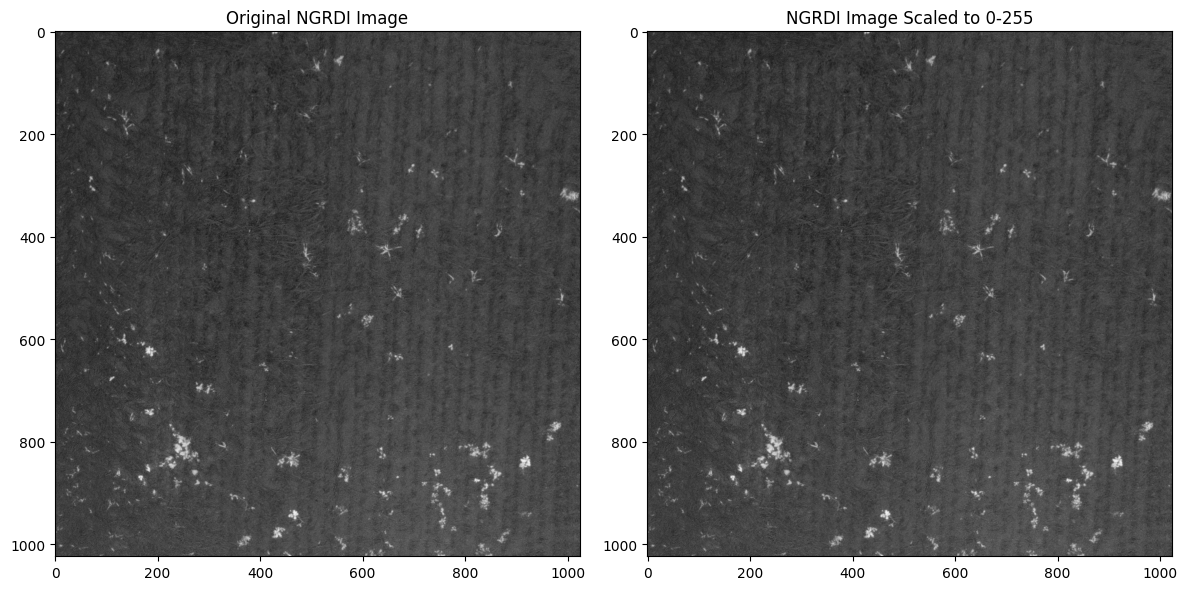

Saved UTF-8 encoded image to /home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_ngrdi_255.tif


100%|██████████| 714/714 [00:07<00:00, 93.64it/s] 


In [87]:
IMAGE_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/NGRDI/tile_1_7_ngrdi.tif"

with rasterio.open(IMAGE_PATH) as src:
    img = src.read(1)

print(img.dtype)
print(img.shape)
print("Max img value: ", img.max())
print("Min img value: ", img.min())


ndvi_min = -1.00
ndvi_max = 1.00
ndvi = img.astype(np.float32)
ndvi_clipped = np.clip(ndvi, ndvi_min, ndvi_max)
ndvi_norm = np.floor(((ndvi_clipped + 1) / 2) * 255).astype(np.uint8)

print(ndvi_norm.dtype)
print(ndvi_norm.shape)
print("Max img value: ", ndvi_norm.max())
print("Min img value: ", ndvi_norm.min())

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original NGRDI Image")
plt.imshow(img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("NGRDI Image Scaled to 0-255")
plt.imshow(ndvi_norm, cmap='gray')

plt.tight_layout()
plt.show()

# Save the UTF-8 encoded image
output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_ngrdi_255.tif"
with rasterio.open(output_path, 'w', driver='GTiff', height=ndvi_norm.shape[0],
                   width=ndvi_norm.shape[1], count=1, dtype=ndvi_norm.dtype) as dst:
    dst.write(ndvi_norm, 1)
print(f"Saved UTF-8 encoded image to {output_path}")

#save original image for comparison
original_output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_ngrdi_original.tif"
with rasterio.open(original_output_path, 'w', driver='GTiff', height=img.shape[0],
                   width=img.shape[1], count=1, dtype=img.dtype) as dst:
    dst.write(img, 1)

    INPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/NGRDI"
OUTPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces_utf8/NGRDI"

os.makedirs(OUTPUT_PATH, exist_ok=True)


for filepath in tqdm.tqdm(glob.glob(os.path.join(INPUT_PATH, "*.tif"))):
    filename = os.path.basename(filepath)
    with rasterio.open(filepath) as src:
        img = src.read(1)
    
    ndvi = img.astype(np.float32)
    ndvi_clipped = np.clip(ndvi, ndvi_min, ndvi_max)
    ndvi_norm = np.floor(((ndvi_clipped + 1) / 2) * 255).astype(np.uint8)

    output_path = os.path.join(OUTPUT_PATH, filename)
    with rasterio.open(output_path, 'w', driver='GTiff', height=ndvi_norm.shape[0],
                       width=ndvi_norm.shape[1], count=1, dtype=ndvi_norm.dtype) as dst:
        dst.write(ndvi_norm, 1)
    



float32
(1024, 1024)
Max img value:  9.453235
Min img value:  0.91152126
uint8
(1024, 1024)
Max img value:  255
Min img value:  25


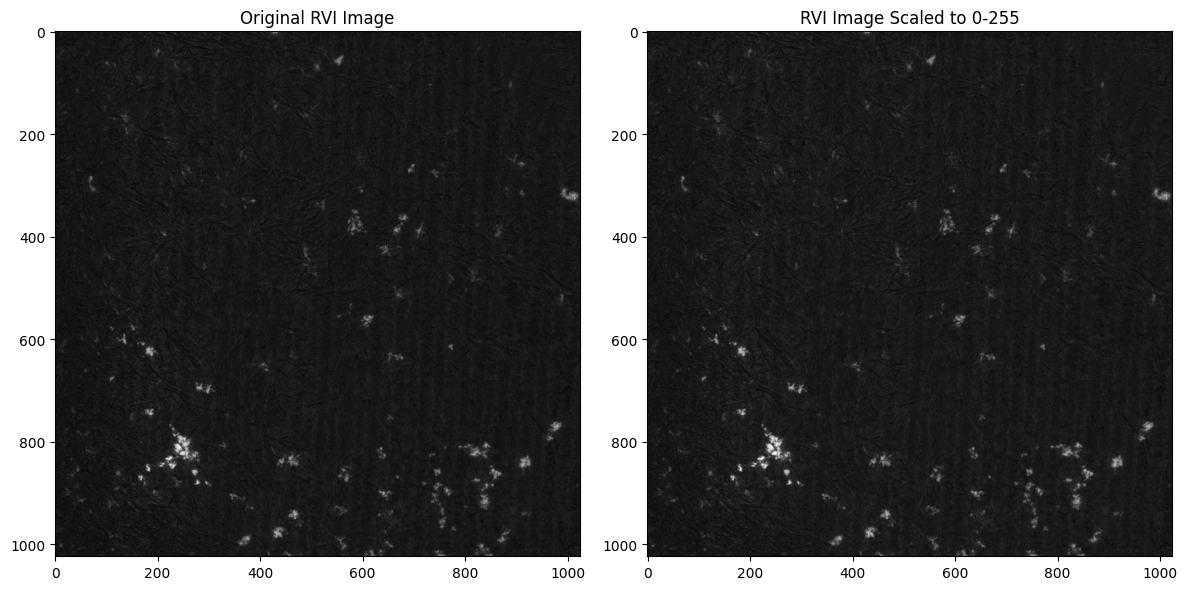

Saved UTF-8 encoded image to /home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_rvi_255.tif


100%|██████████| 714/714 [00:07<00:00, 90.64it/s] 


In [88]:
IMAGE_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/RVI/tile_1_7_rvi.tif"

with rasterio.open(IMAGE_PATH) as src:
    img = src.read(1)

print(img.dtype)
print(img.shape)
print("Max img value: ", img.max())
print("Min img value: ", img.min())

# Convert index image to UTF-8 encoded image
# ngrdi_o_255_img = np.floor(((img + 1) / 2) * 255).astype(np.uint8)

rvi_min = 0.00
rvi_max = 9.00
rvi = img.astype(np.float32)
rvi_clipped = np.clip(rvi, rvi_min, rvi_max)
rvi_norm = ((rvi_clipped - rvi_min) / (rvi_max - rvi_min) * 255).astype(np.uint8)


print(rvi_norm.dtype)
print(rvi_norm.shape)
print("Max img value: ", rvi_norm.max())
print("Min img value: ", rvi_norm.min())

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original RVI Image")
plt.imshow(img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("RVI Image Scaled to 0-255")
plt.imshow(rvi_norm, cmap='gray')

plt.tight_layout()
plt.show()

# Save the UTF-8 encoded image
output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_rvi_255.tif"
with rasterio.open(output_path, 'w', driver='GTiff', height=rvi_norm.shape[0],
                   width=rvi_norm.shape[1], count=1, dtype=rvi_norm.dtype) as dst:
    dst.write(rvi_norm, 1)

print(f"Saved UTF-8 encoded image to {output_path}")

#save original image for comparison
original_output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_rvi_original.tif"
with rasterio.open(original_output_path, 'w', driver='GTiff', height=img.shape[0],
                   width=img.shape[1], count=1, dtype=img.dtype) as dst:
    dst.write(img, 1)

INPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/RVI"
OUTPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces_utf8/RVI"

os.makedirs(OUTPUT_PATH, exist_ok=True)


for filepath in tqdm.tqdm(glob.glob(os.path.join(INPUT_PATH, "*.tif"))):
    filename = os.path.basename(filepath)
    with rasterio.open(filepath) as src:
        img = src.read(1)
    
    rvi = img.astype(np.float32)
    rvi_norm = norm_index_image(rvi, rvi_min, rvi_max)

    output_path = os.path.join(OUTPUT_PATH, filename)
    with rasterio.open(output_path, 'w', driver='GTiff', height=rvi_norm.shape[0],
                       width=rvi_norm.shape[1], count=1, dtype=rvi_norm.dtype) as dst:
        dst.write(rvi_norm, 1)
    



float32
(1024, 1024)
Max img value:  3323.2256
Min img value:  -11340.421
uint8
(1024, 1024)
Max img value:  174
Min img value:  0


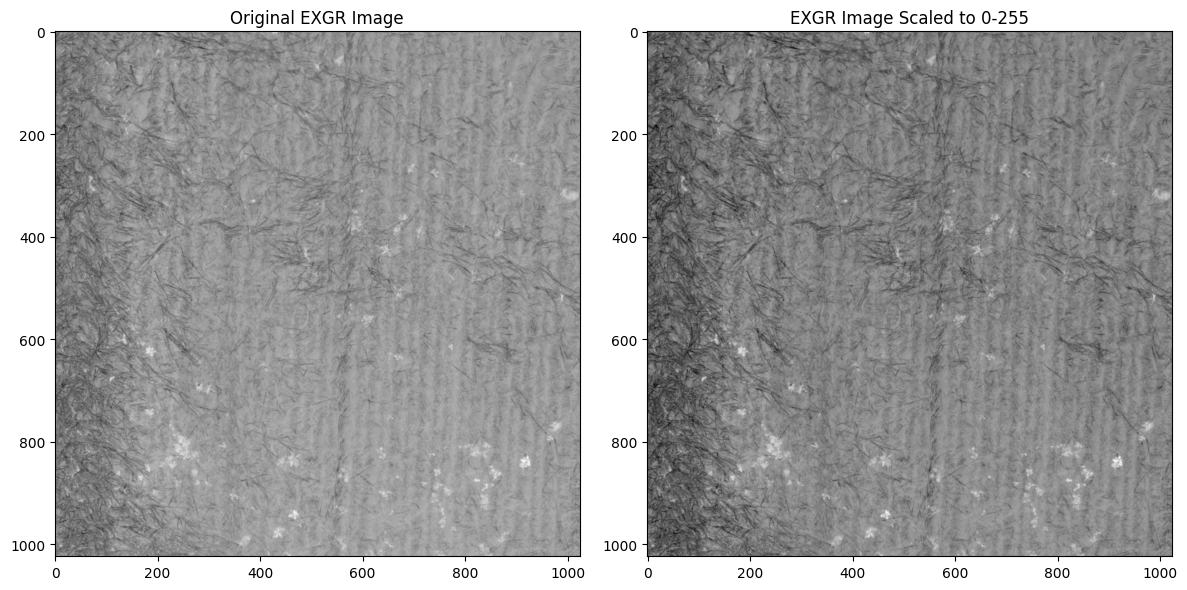

Saved UTF-8 encoded image to /home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_exgr_255.tif


100%|██████████| 714/714 [00:08<00:00, 88.95it/s] 


In [89]:
IMAGE_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/EXGR/tile_1_7_exgr.tif"

with rasterio.open(IMAGE_PATH) as src:
    img = src.read(1)

print(img.dtype)
print(img.shape)
print("Max img value: ", img.max())
print("Min img value: ", img.min())

# Convert index image to UTF-8 encoded image
# ngrdi_o_255_img = np.floor(((img + 1) / 2) * 255).astype(np.uint8)

rvi_min = -9000.00
rvi_max = 9000.00
rvi = img.astype(np.float32)
rvi_clipped = np.clip(rvi, rvi_min, rvi_max)
rvi_norm = ((rvi_clipped - rvi_min) / (rvi_max - rvi_min) * 255).astype(np.uint8)


print(rvi_norm.dtype)
print(rvi_norm.shape)
print("Max img value: ", rvi_norm.max())
print("Min img value: ", rvi_norm.min())

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original EXGR Image")
plt.imshow(img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("EXGR Image Scaled to 0-255")
plt.imshow(rvi_norm, cmap='gray')

plt.tight_layout()
plt.show()

# Save the UTF-8 encoded image
output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_exgr_255.tif"
with rasterio.open(output_path, 'w', driver='GTiff', height=rvi_norm.shape[0],
                   width=rvi_norm.shape[1], count=1, dtype=rvi_norm.dtype) as dst:
    dst.write(rvi_norm, 1)

print(f"Saved UTF-8 encoded image to {output_path}")

#save original image for comparison
original_output_path = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/test/tile_1_7_exgr_original.tif"
with rasterio.open(original_output_path, 'w', driver='GTiff', height=img.shape[0],
                   width=img.shape[1], count=1, dtype=img.dtype) as dst:
    dst.write(img, 1)


INPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces/EXGR"
OUTPUT_PATH = "/home/samuel/SDU/MasterThesis/Orthomosaics/large/processed_output/image_tiles_indeces_utf8/EXGR"

os.makedirs(OUTPUT_PATH, exist_ok=True)

rvi_min = -9000.00
rvi_max = 9000.00

for filepath in tqdm.tqdm(glob.glob(os.path.join(INPUT_PATH, "*.tif"))):
    filename = os.path.basename(filepath)
    with rasterio.open(filepath) as src:
        img = src.read(1)
    
    rvi = img.astype(np.float32)
    rvi_norm = norm_index_image(rvi, rvi_min, rvi_max)

    output_path = os.path.join(OUTPUT_PATH, filename)
    with rasterio.open(output_path, 'w', driver='GTiff', height=rvi_norm.shape[0],
                       width=rvi_norm.shape[1], count=1, dtype=rvi_norm.dtype) as dst:
        dst.write(rvi_norm, 1)
    
